
# 📊 **Examen Unidad 1: Dataset Seleccionado Datos del Dengue Ene2021 - Ago2025**

# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------

## 📝 **Introducción**

En este proyecto se realiza un análisis estadístico utilizando un dataset real de casos de dengue.

El objetivo es aplicar conceptos de Probabilidad y Estadística mediante programación en Python y Jupyter Notebook.

Se analizarán temas como:

- Clasificación de variables
- Espacio muestral
- Rango
- Media muestral
- Varianza muestral
- Desviación estándar
- Probabilidad binomial
- Estimadores estadísticos
- Interpretación de resultados
- Éxito y fracaso probabilístico


## **📥 Importación de Librerías**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## **💾 Carga del Dataset**

In [2]:

df = pd.read_excel('Datos_Dengue_MSP_Ene2021_Ago2025.xlsx')

print("Dimensiones del dataset:")
print(df.shape)

df.head()


Dimensiones del dataset:
(35749, 33)


,Año,Semana,Institución,Unidad operativa,Unicodigo,Zona,Distrito,Cod_Provincia,Provincia,Cod_Canton,...,15-19 M,20-49 H,20-49 M,50-64 H,50-64 M,65+ H,65+ M,Hombres,Mujeres,Total
0,2021,1,IESS,000717-HOSPITAL DEL IESS DE ESMERALDAS,'000717,ZONA 1,ESMERALDAS,'08,ESMERALDAS,'0801,...,0,0,0,0,0,0,0,0,1,1
1,2021,1,IESS,000929-HOSPITAL DE DURAN NIVEL I,'000929,ZONA 8,DURAN,'09,GUAYAS,'0907,...,0,6,3,1,1,0,1,12,8,20
2,2021,1,IESS,000936-000936-CCQA SUR VALDIVIA,'000936,ZONA 8,"PUNA, ESTUARIO DEL RIO GUAYAS, XIMENA 1",'09,GUAYAS,'0901,...,0,1,1,0,0,0,0,2,1,3
3,2021,1,IESS,000939-CENTRO DE ESPECIALIDADES DAULE,'000939,ZONA 5,"DAULE,NOBOL,SANTA LUCIA",'09,GUAYAS,'0906,...,0,2,1,0,0,0,0,2,1,3
4,2021,1,IESS,001238-HOSPITAL DE BABAHOYO NIVEL II,'001238,ZONA 5,"BABA,BABAHOYO,MONTALVO",'12,LOS RIOS,'1201,...,0,4,0,1,0,0,0,5,1,6



# **🔍 Limpieza y Transformación de Datos**

Antes de realizar cálculos estadísticos es necesario:

- Verificar valores nulos
- Eliminar inconsistencias
- Validar tipos de datos

Esto permite obtener resultados estadísticos más confiables.


In [3]:

print("Valores nulos por columna:\n")

print(df.isnull().sum())

# Eliminación de valores nulos
df = df.dropna()

print("\nDimensiones luego de la limpieza:")
print(df.shape)


Valores nulos por columna:

Año                 0
Semana              0
Institución         0
Unidad operativa    0
Unicodigo           0
Zona                0
Distrito            0
Cod_Provincia       0
Provincia           0
Cod_Canton          0
Canton              0
Cod_Parroquia       0
Parroquia           0
Evento              0
< 1 H               0
< 1 M               0
1 - 4 H             0
1 - 4 M             0
5 - 9 H             0
5 - 9 M             0
10-14 H             0
10-14 M             0
15-19 H             0
15-19 M             0
20-49 H             0
20-49 M             0
50-64 H             0
50-64 M             0
65+ H               0
65+ M               0
Hombres             0
Mujeres             0
Total               0
dtype: int64

Dimensiones luego de la limpieza:
(35749, 33)



# **📊 Clasificación de Variables**

Las variables del dataset pueden clasificarse según su naturaleza estadística.


| Variable | Tipo | Justificación |
|---|---|---|
| Semana | Discreta | Representa un conteo de semanas epidemiológicas. Solo puede tomar valores enteros finitos. |
| Zona | Discreta/Categórica | Representa categorías geográficas como Zona 1, Zona 5, etc. No admite valores intermedios. |
| Hombres | Discreta | Corresponde al número de casos registrados en hombres. Es un conteo entero. |
| Mujeres | Discreta | Corresponde al número de casos registrados en mujeres. También es un conteo entero. |
| Total | Discreta | Es la suma total de casos reportados. Solo toma valores enteros. |


Las variables son discretas porque representan cantidades enteras.


In [17]:

clasificacion = pd.DataFrame({
    'Variable': ['Semana','Zona', 'Hombres', 'Mujeres', 'Total'],
    'Tipo': ['Discreta','Discreta/Categorica', 'Discreta', 'Discreta', 'Discreta']
})

clasificacion


,Variable,Tipo
0,Semana,Discreta
1,Zona,Discreta/Categorica
2,Hombres,Discreta
3,Mujeres,Discreta
4,Total,Discreta



# **🎲 Espacio Muestral**

El espacio muestral corresponde al conjunto de todos los posibles valores observados en la variable de estudio.

En este proyecto:

$$
S = \{x_1, x_2, x_3, ..., x_n\}
$$

donde cada valor representa una cantidad de casos de dengue observados.


In [5]:

x = df['Total']

espacio_muestral = sorted(x.unique())

print("Primeros valores del espacio muestral:\n")

print(espacio_muestral[:20])

print("\nCantidad total de elementos:")
print(len(espacio_muestral))


Primeros valores del espacio muestral:

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Cantidad total de elementos:
81



# **🎲 Rango**

El rango mide la amplitud total de los datos.

Se calcula mediante:

$$
R = X_{max} - X_{min}
$$

Interpretación:

- Un rango alto indica gran variabilidad.
- Un rango bajo indica datos más concentrados.


In [8]:

valor_maximo = np.max(x)
valor_minimo = np.min(x)

rango = valor_maximo - valor_minimo

print("Valor máximo:", valor_maximo)
print("Valor mínimo:", valor_minimo)
print("Rango:", rango)


Valor máximo: 100
Valor mínimo: 1
Rango: 99



# **📏 Media Muestral y Esperanza Matemática**

La media muestral representa el promedio de los datos observados.

También puede interpretarse como la esperanza matemática:

$$
E(X)=\frac{\sum x_i}{n}
$$

donde:

- ${x_i}$ : valores observados
- ${n}$: número de observaciones


In [9]:

suma = 0

for valor in x:
    suma += valor

media_manual = suma / len(x)

print("Media manual:")
print(media_manual)

media_numpy = np.mean(x)

print("\nMedia con NumPy:")
print(media_numpy)


Media manual:
3.849506279895941

Media con NumPy:
3.849506279895941



# **Interpretación de la Media**

La media representa el promedio esperado de casos de dengue.

Si la media es elevada, significa que existe una tendencia a registrar altas cantidades de casos.



# **📉 Varianza Muestral**

La varianza mide la dispersión de los datos respecto a la media.

$$
Var(X)=\frac{\sum (x_i-\mu)^2}{n-1}
$$

Interpretación:

- Varianza baja → datos concentrados
- Varianza alta → datos dispersos


In [10]:

suma_var = 0

for valor in x:
    suma_var += (valor - media_manual) ** 2

varianza_manual = suma_var / (len(x)-1)

print("Varianza manual:")
print(varianza_manual)

print("\nVarianza con NumPy:")
print(np.var(x, ddof=1))


Varianza manual:
39.47595232700098

Varianza con NumPy:
39.47595232700098



# **⚙️ Explicación de `ddof=1`**

`ddof` significa:

$$
\text{Delta Degrees of Freedom}
$$

Cuando se trabaja con muestras se utiliza:

$$
n-1
$$

Esto se conoce como Corrección de Bessel.

## **❓ ¿Por qué es importante?**

Usar únicamente \(n\) subestima la varianza real.

Por ello:

- `ddof=0` → Varianza poblacional
- `ddof=1` → Varianza muestral


In [11]:

var_poblacional = np.var(x, ddof=0)

var_muestral = np.var(x, ddof=1)

print("Varianza poblacional:")
print(var_poblacional)

print("\nVarianza muestral:")
print(var_muestral)

print("\nDiferencia:")
print(var_muestral - var_poblacional)


Varianza poblacional:
39.47484807367006

Varianza muestral:
39.47595232700098

Diferencia:
0.0011042533309222335



# **⚙️ Desviación Estándar**

La desviación estándar mide cuánto se alejan los datos respecto a la media.

$$
\sigma = \sqrt{Var(X)}
$$

Interpretación:

- Valor pequeño → datos cercanos a la media
- Valor grande → datos muy dispersos


In [12]:

desviacion = np.sqrt(varianza_manual)

print("Desviación estándar:")
print(desviacion)


Desviación estándar:
6.282989123578123



# **💻 Varianza Alta y Varianza Baja**

## **📉 Varianza Baja**
Significa que la mayoría de los datos están cercanos a la media.

## **📈 Varianza Alta**
Significa que los datos presentan gran dispersión y variabilidad.

En epidemiología esto puede indicar cambios bruscos en los casos reportados.


In [13]:

if varianza_manual < 100:
    print("La varianza es baja.")
    print("Los datos presentan poca dispersión.")

elif varianza_manual < 1000:
    print("La varianza es moderada.")
    print("Existe dispersión media.")

else:
    print("La varianza es alta.")
    print("Los datos presentan gran dispersión.")


La varianza es baja.
Los datos presentan poca dispersión.



# 📂 Estimadores Estadísticos

Los estimadores permiten aproximar parámetros poblacionales.

En este proyecto:

- La media muestral estima la media poblacional.
- La varianza muestral estima la dispersión poblacional.
- La desviación estándar mide la variabilidad.

Estos indicadores ayudan a comprender el comportamiento del dengue.



#🎲 Probabilidad Binomial

Se analizará el evento:

> "Una semana presenta casos superiores a la media"

En una distribución binomial:

- Éxito → casos superiores a la media
- Fracaso → casos inferiores o iguales a la media


In [15]:

casos_exito = np.sum(x < media_manual)

n = len(x)

p = casos_exito / n

q = 1 - p

print("Número de éxitos:", casos_exito)

print("\nProbabilidad de éxito:")
print(p)

print("\nProbabilidad de fracaso:")
print(q)


Número de éxitos: 25948

Probabilidad de éxito:
0.7258384849925872

Probabilidad de fracaso:
0.2741615150074128



# 🎯 **Interpretación del Éxito y Fracaso**

## ✅ **Éxito**
Representa la probabilidad de encontrar semanas con casos con valores iguales o inferiores a la media.

## ❌ **Fracaso**
Representa semanas con valores superiores a la media.

Esto permite analizar la frecuencia de semanas críticas de dengue.



# **🧮 Histograma de Distribución**


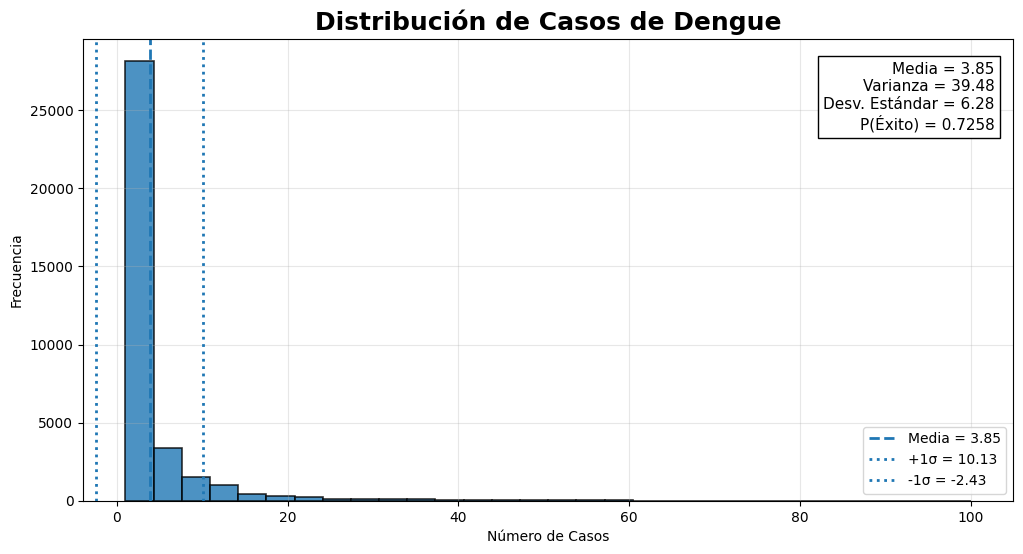

In [16]:

plt.figure(figsize=(12,6))

plt.hist(
    x,
    bins=30,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

plt.axvline(
    media_manual,
    linestyle='--',
    linewidth=2,
    label=f'Media = {media_manual:.2f}'
)

plt.axvline(
    media_manual + desviacion,
    linestyle=':',
    linewidth=2,
    label=f'+1σ = {media_manual + desviacion:.2f}'
)

plt.axvline(
    media_manual - desviacion,
    linestyle=':',
    linewidth=2,
    label=f'-1σ = {media_manual - desviacion:.2f}'
)

plt.text(
    0.98,
    0.95,
    f'Media = {media_manual:.2f}\n'
    f'Varianza = {varianza_manual:.2f}\n'
    f'Desv. Estándar = {desviacion:.2f}\n'
    f'P(Éxito) = {p:.4f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.title(
    'Distribución de Casos de Dengue',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Número de Casos')
plt.ylabel('Frecuencia')

plt.grid(alpha=0.3)

plt.legend()

plt.show()



#**📋 Interpretación Final**

El análisis estadístico realizado permitió comprender el comportamiento de los casos de dengue mediante herramientas descriptivas y probabilísticas aplicadas sobre un dataset real.

La esperanza matemática o media muestral permitió calcular el promedio esperado de casos de dengue utilizando:

$$
E(X)=\frac{\sum x_i}{n}
$$

donde:

- ${x_i}$ representa cada valor observado
- ${n}$ representa el número total de observaciones

Este valor permitió identificar una tendencia general de los casos registrados en el dataset.

Por otro lado, la varianza muestral permitió medir la dispersión de los datos respecto a la media mediante la fórmula:

$$
Var(X)=\frac{\sum (x_i-\mu)^2}{n-1}
$$

Una varianza elevada indica mayor variabilidad en los casos de dengue entre semanas, mientras que una varianza baja representa datos más estables y concentrados alrededor de la media.

Además, la desviación estándar:

$$
\sigma = \sqrt{Var(X)}
$$

permitió medir cuánto se alejan los datos respecto al promedio observado.

También se aplicó un modelo probabilístico de Bernoulli y Binomial para clasificar eventos de éxito y fracaso.

En este proyecto se definió:

- **Éxito:** semanas con casos inferiores o iguales a la media.
- **Fracaso:** semanas con casos superiores a la media.

La probabilidad de éxito se calculó mediante:

$$
P(X=1)=\frac{\text{Número de semanas con casos bajos}}{\text{Total de semanas}}
$$

mientras que la probabilidad de fracaso se obtuvo con:

$$
P(X=0)=1-P(X=1)
$$

Estos resultados permitieron interpretar estadísticamente la frecuencia de semanas críticas y semanas controladas dentro del comportamiento epidemiológico del dengue.

Finalmente, la programación en Python permitió automatizar cálculos, implementar fórmulas manualmente, comparar resultados con NumPy y representar gráficamente la distribución de los datos mediante histogramas, facilitando así una mejor comprensión e interpretación de la información estadística obtenida.